# **Laboratorio #4 -  Pipeline de NLP con Hugging Face**

* Paula Barillas - 22764
* Gerardo Pineda - 22880

- Link del repositorio: https://github.com/paulabaal12/LAB4-NLP

In [14]:
import pandas as pd
from transformers import pipeline
import matplotlib.pyplot as plt

In [15]:
reseñas = [
    {"review_id": 1, "text": "La comida en Sabor Maya estuvo increíble, el chuchito era delicioso y el servicio de Don Carlos fue excelente."},
    {"review_id": 2, "text": "Pésimo servicio en El Fogón Chapín, esperamos una hora y la comida llegó fría."},
    {"review_id": 3, "text": "El restaurante Kakaw en Antigua Guatemala tiene un ambiente hermoso, pero los precios son muy altos."},
    {"review_id": 4, "text": "No fue una mala experiencia, la verdad me sorprendió gratamente el sabor de los tamales en Rincón Típico."},
    {"review_id": 5, "text": "La pizza no estuvo nada rica, definitivamente no vuelvo a Pizza Nostra."},
    {"review_id": 6, "text": "El café de Cafetería Luna en Xela es de los mejores que he probado, ambiente muy acogedor."},
    {"review_id": 7, "text": "En Marisquería El Ancla, en Puerto Barrios, el pescado olía raro y el mesero fue grosero."},
    {"review_id": 8, "text": "La Terraza en Zona 10 tiene una vista espectacular, aunque la comida es bastante mediocre para el precio."},
    {"review_id": 9, "text": "La chef Andrea Morales de Fusión Gourmet preparó un menú increíble, cada plato fue una sorpresa."},
    {"review_id": 10, "text": "La Taquería El Compadre me decepcionó, los tacos estaban secos y fríos."},
    {"review_id": 11, "text": "Cenar en Restaurante Panorama, frente al Lago de Atitlán en Panajachel, fue una experiencia inolvidable."},
    {"review_id": 12, "text": "El Comedor de Doña Rosa tiene comida casera muy rica y a buen precio, se los recomiendo."},
    {"review_id": 13, "text": "El sushi en Sushi Itto Guatemala está bien, aunque esperaba más variedad en el menú."},
    {"review_id": 14, "text": "Qué maravilla, dos horas de espera en El Portal del Ángel para que me sirvieran arroz frío. Simplemente espectacular."},
    {"review_id": 15, "text": "Rico."},
    {"review_id": 16, "text": "Malísimo."},
    {"review_id": 17, "text": "La comida taba bien rika pero el serbicio pesimo, nunka volvemos."},
    {"review_id": 18, "text": "Fuimos a Zúmbala Café y la verdad ni sabíamos bien dónde quedaba, la comida estuvo pasable."},
    {"review_id": 19, "text": "El chef Ricardo Paredes de Restaurante El Establo nos preparó un platillo excelente, muy recomendado."},
    {"review_id": 20, "text": "El Wendy's de la zona 1 tardó demasiado en entregar mi pedido y llegó incompleto."},
    {"review_id": 21, "text": "El café de Café Barista, cerca de la Universidad del Valle, está rico pero es carísimo para lo que ofrecen."},
    {"review_id": 22, "text": "El Hotel y Restaurante Atitlán superó nuestras expectativas, personal muy amable y comida deliciosa."},
    {"review_id": 23, "text": "No puedo decir que fue mala la cena en Los Girasoles, de hecho me encantó cada platillo."},
    {"review_id": 24, "text": "No fue una experiencia agradable en Cafetería El Trébol, el ambiente estaba sucio y desorganizado."},
    {"review_id": 25, "text": "El postre en Chocolatería Q estuvo exquisito, pero el mesero Luis fue muy grosero con nosotros."},
    {"review_id": 26, "text": "La Cocina de Mama es simplemente maravillosa, el chef Fernando López tiene un talento increíble, todo estaba perfecto desde la entrada hasta el postre."},
    {"review_id": 27, "text": "El Burger King de la zona 4 nos dio hamburguesas frías y el local estaba sucio, pésima experiencia."},
    {"review_id": 28, "text": "Recorrimos Livingston y Río Dulce, y cenamos en el restaurante Rango Verde, todo estuvo delicioso."},
    {"review_id": 29, "text": "El gerente Sergio Aguilar de Café Barrista nos atendió excelente, resolvió todo rapidísimo."},
    {"review_id": 30, "text": "El lugar está bien, ni tan bueno ni tan malo, normal."},
    {"review_id": 31, "text": "No diría que la comida es mala, pero tampoco es algo que recomendaría en Restaurante Bella Vista."},
    {"review_id": 32, "text": "El desayuno en Panadería San Martín, en Cobán, fue sencillo pero muy sabroso y el precio justo."},
]

df_reseñas = pd.DataFrame(reseñas)
print(f"Total de reseñas: {len(df_reseñas)}")
df_reseñas.head()


Total de reseñas: 32


,review_id,text
0,1,"La comida en Sabor Maya estuvo increíble, el c..."
1,2,"Pésimo servicio en El Fogón Chapín, esperamos ..."
2,3,El restaurante Kakaw en Antigua Guatemala tien...
3,4,"No fue una mala experiencia, la verdad me sorp..."
4,5,"La pizza no estuvo nada rica, definitivamente ..."


#### **Parte A — Análisis de sentimiento**

In [16]:
sentiment = pipeline(
    "sentiment-analysis",
    model="pysentimiento/robertuito-sentiment-analysis"
)

textos = df_reseñas["text"].tolist()
resultados_sentimiento = sentiment(textos, batch_size=8, truncation=True)
mapa_sentimiento = {"POS": "POSITIVE", "NEG": "NEGATIVE", "NEU": "NEUTRAL"}

df_reseñas["sentiment"] = [mapa_sentimiento.get(r["label"], r["label"]) for r in resultados_sentimiento]
df_reseñas["sentiment_score"] = [round(r["score"], 4) for r in resultados_sentimiento]

df_reseñas[["review_id", "text", "sentiment", "sentiment_score"]]

config.json:   0%|          | 0.00/925 [00:00<?, ?B/s]

C:\Users\rebe1\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\rebe1\.cache\huggingface\hub\models--pysentimiento--robertuito-sentiment-analysis. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/435M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

Device set to use cpu


,review_id,text,sentiment,sentiment_score
0,1,"La comida en Sabor Maya estuvo increíble, el c...",POSITIVE,0.9768
1,2,"Pésimo servicio en El Fogón Chapín, esperamos ...",NEGATIVE,0.9742
2,3,El restaurante Kakaw en Antigua Guatemala tien...,POSITIVE,0.8564
3,4,"No fue una mala experiencia, la verdad me sorp...",POSITIVE,0.9717
4,5,"La pizza no estuvo nada rica, definitivamente ...",NEGATIVE,0.8710
5,6,El café de Cafetería Luna en Xela es de los me...,POSITIVE,0.9767
6,7,"En Marisquería El Ancla, en Puerto Barrios, el...",NEGATIVE,0.9563
7,8,La Terraza en Zona 10 tiene una vista espectac...,POSITIVE,0.7973
8,9,La chef Andrea Morales de Fusión Gourmet prepa...,POSITIVE,0.9745
9,10,"La Taquería El Compadre me decepcionó, los tac...",NEGATIVE,0.9797


#### **Parte B — Reconocimiento de entidades nombradas (NER)**

In [17]:
ner = pipeline(
    "token-classification",
    model="mrm8488/bert-spanish-cased-finetuned-ner",
    aggregation_strategy="simple"
)

def extraer_entidades(texto):
    ents = ner(texto)
    return [
        {"text": e["word"], "label": e["entity_group"], "score": round(float(e["score"]), 4)}
        for e in ents
    ]

df_reseñas["entities"] = df_reseñas["text"].apply(extraer_entidades)
df_reseñas[["review_id", "text", "entities"]]

config.json:   0%|          | 0.00/829 [00:00<?, ?B/s]

C:\Users\rebe1\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\rebe1\.cache\huggingface\hub\models--mrm8488--bert-spanish-cased-finetuned-ner. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


pytorch_model.bin:   0%|          | 0.00/439M [00:00<?, ?B/s]

Some weights of the model checkpoint at mrm8488/bert-spanish-cased-finetuned-ner were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/439M [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cpu
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


,review_id,text,entities
0,1,"La comida en Sabor Maya estuvo increíble, el c...","[{'text': 'Sab', 'label': 'LOC', 'score': 0.89..."
1,2,"Pésimo servicio en El Fogón Chapín, esperamos ...","[{'text': 'El Fogón Chapín', 'label': 'LOC', '..."
2,3,El restaurante Kakaw en Antigua Guatemala tien...,"[{'text': 'Kakaw', 'label': 'MISC', 'score': 0..."
3,4,"No fue una mala experiencia, la verdad me sorp...","[{'text': 'Rincón Típico', 'label': 'LOC', 'sc..."
4,5,"La pizza no estuvo nada rica, definitivamente ...","[{'text': 'Pizza Nostra', 'label': 'MISC', 'sc..."
5,6,El café de Cafetería Luna en Xela es de los me...,"[{'text': 'Ca', 'label': 'ORG', 'score': 0.995..."
6,7,"En Marisquería El Ancla, en Puerto Barrios, el...","[{'text': 'Maris', 'label': 'ORG', 'score': 0...."
7,8,La Terraza en Zona 10 tiene una vista espectac...,"[{'text': 'Terraza', 'label': 'LOC', 'score': ..."
8,9,La chef Andrea Morales de Fusión Gourmet prepa...,"[{'text': 'Andrea Morales', 'label': 'PER', 's..."
9,10,"La Taquería El Compadre me decepcionó, los tac...","[{'text': 'Taquería El Compadre', 'label': 'OR..."


#### **Parte C — Flujo integrado**

In [27]:
resultado_integrado = []

for _, row in df_reseñas.iterrows():
    resultado_integrado.append({
        "review_id": int(row["review_id"]),
        "text": row["text"],
        "sentiment": row["sentiment"],
        "sentiment_score": row["sentiment_score"],
        "entities": row["entities"],
    })

resultado_integrado[0]


{'review_id': 1,
 'text': 'La comida en Sabor Maya estuvo increíble, el chuchito era delicioso y el servicio de Don Carlos fue excelente.',
 'sentiment': 'POSITIVE',
 'sentiment_score': 0.9768,
 'entities': [{'text': 'Sab', 'label': 'LOC', 'score': 0.8976},
  {'text': '##or Maya', 'label': 'LOC', 'score': 0.8396},
  {'text': 'Don Carlos', 'label': 'PER', 'score': 0.9977}]}

#### **Parte D — Estadísticas**

In [28]:
conteo_por_etiqueta = df_reseñas["sentiment"].value_counts()
print("Reseñas por etiqueta:")
print(conteo_por_etiqueta)

Reseñas por etiqueta:
sentiment
POSITIVE    19
NEGATIVE    11
NEUTRAL      2
Name: count, dtype: int64


In [29]:

# Score promedio
score_promedio = df_reseñas["sentiment_score"].mean()
print(f"\nScore promedio de sentimiento: {score_promedio:.4f}")


Score promedio de sentimiento: 0.8862


In [30]:
# 5 reseñas de menor confianza
menor_confianza = df_reseñas.nsmallest(5, "sentiment_score")[["review_id", "text", "sentiment", "sentiment_score"]]
print("\n5 reseñas de menor confianza:")
print(menor_confianza)


5 reseñas de menor confianza:
    review_id                                               text sentiment  \
22         23  No puedo decir que fue mala la cena en Los Gir...  POSITIVE   
14         15                                              Rico.   NEUTRAL   
17         18  Fuimos a Zúmbala Café y la verdad ni sabíamos ...  POSITIVE   
29         30  El lugar está bien, ni tan bueno ni tan malo, ...  POSITIVE   
24         25  El postre en Chocolatería Q estuvo exquisito, ...  NEGATIVE   

    sentiment_score  
22           0.3820  
14           0.4480  
17           0.6659  
29           0.7562  
24           0.7770  


In [31]:
# promedio de entidades por reseña
df_reseñas["n_entities"] = df_reseñas["entities"].apply(len)
promedio_entidades = df_reseñas["n_entities"].mean()
print(f"\nPromedio de entidades por reseña: {promedio_entidades:.2f}")



Promedio de entidades por reseña: 2.00


In [32]:
# entidad encontrados
tipos_entidad = set()
for ents in df_reseñas["entities"]:
    for e in ents:
        tipos_entidad.add(e["label"])
print(f"\nTipos de entidad encontrados: {tipos_entidad}")


Tipos de entidad encontrados: {'ORG', 'PER', 'LOC', 'MISC'}


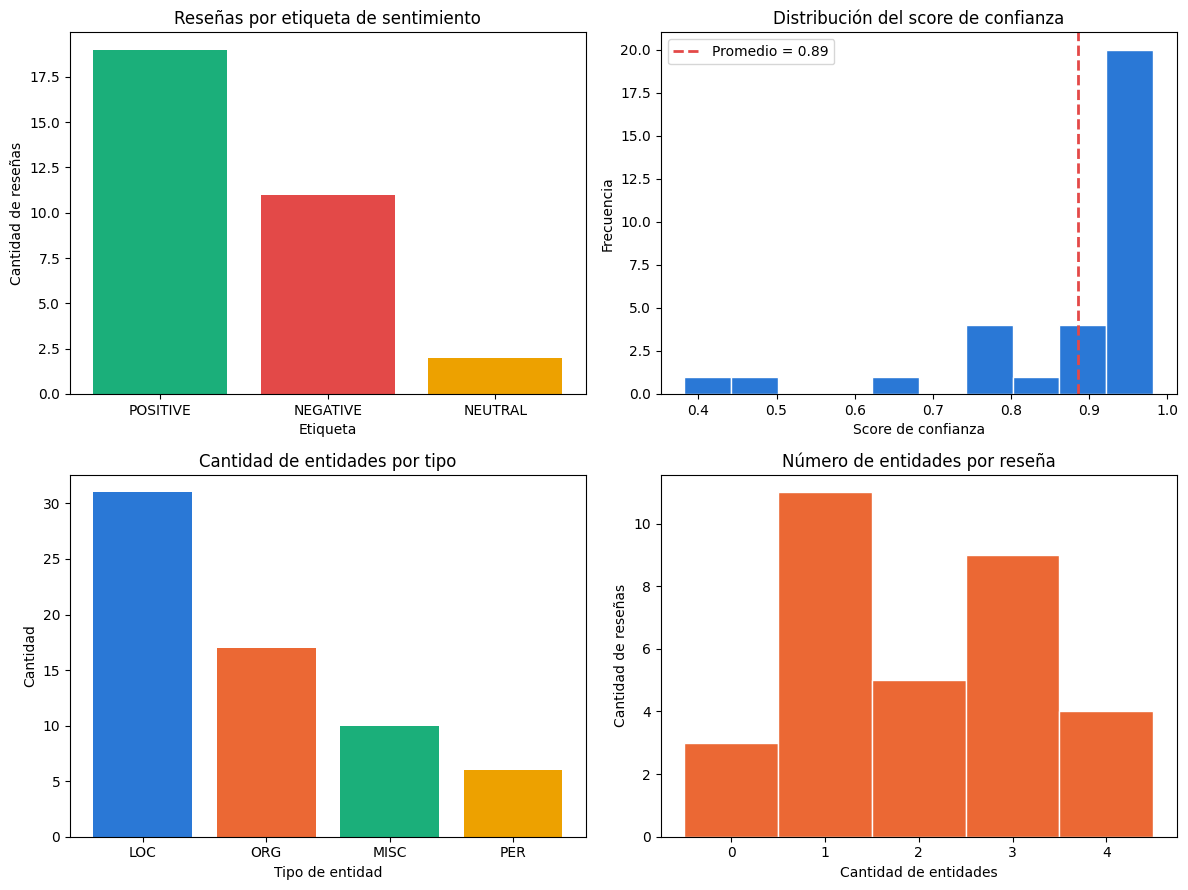

In [33]:
COLOR_POS, COLOR_NEG, COLOR_NEU = "#1baf7a", "#e34948", "#eda100"
COLOR_BLUE, COLOR_ORANGE, COLOR_AQUA, COLOR_YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
color_sentimiento = {"POSITIVE": COLOR_POS, "NEGATIVE": COLOR_NEG, "NEUTRAL": COLOR_NEU}

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# reseñas por etiqueta de sentimiento
colores_a = [color_sentimiento.get(et, "#888888") for et in conteo_por_etiqueta.index]
axes[0, 0].bar(conteo_por_etiqueta.index, conteo_por_etiqueta.values, color=colores_a)
axes[0, 0].set_title("Reseñas por etiqueta de sentimiento")
axes[0, 0].set_xlabel("Etiqueta")
axes[0, 0].set_ylabel("Cantidad de reseñas")

# istribución del score de confianza
axes[0, 1].hist(df_reseñas["sentiment_score"], bins=10, color=COLOR_BLUE, edgecolor="white")
axes[0, 1].axvline(score_promedio, color=COLOR_NEG, linestyle="--", linewidth=2, label=f"Promedio = {score_promedio:.2f}")
axes[0, 1].set_title("Distribución del score de confianza")
axes[0, 1].set_xlabel("Score de confianza")
axes[0, 1].set_ylabel("Frecuencia")
axes[0, 1].legend()

# dantidad de entidades por tipo
conteo_entidades = pd.Series(
    [e["label"] for ents in df_reseñas["entities"] for e in ents]
).value_counts()
colores_c = [COLOR_BLUE, COLOR_ORANGE, COLOR_AQUA, COLOR_YELLOW][:len(conteo_entidades)]
axes[1, 0].bar(conteo_entidades.index, conteo_entidades.values, color=colores_c)
axes[1, 0].set_title("Cantidad de entidades por tipo")
axes[1, 0].set_xlabel("Tipo de entidad")
axes[1, 0].set_ylabel("Cantidad")

# número de entidades por reseña
max_ent = int(df_reseñas["n_entities"].max())
axes[1, 1].hist(
    df_reseñas["n_entities"], bins=range(0, max_ent + 2),
    color=COLOR_ORANGE, edgecolor="white", align="left"
)
axes[1, 1].set_title("Número de entidades por reseña")
axes[1, 1].set_xlabel("Cantidad de entidades")
axes[1, 1].set_ylabel("Cantidad de reseñas")
axes[1, 1].set_xticks(range(0, max_ent + 1))

plt.tight_layout()
plt.savefig("laboratorio_4_graficos.png", dpi=150)
plt.show()

In [34]:
df_export = df_reseñas[["review_id", "text", "sentiment", "sentiment_score", "n_entities"]].copy()
df_export["entities"] = df_reseñas["entities"].apply(lambda ents: "; ".join(f"{e['text']}({e['label']},{e['score']})" for e in ents))

df_export.to_csv("laboratorio_4_resultados.csv", index=False)
print("Guardado: laboratorio_4_resultados.csv")
df_export.head()

Guardado: laboratorio_4_resultados.csv


,review_id,text,sentiment,sentiment_score,n_entities,entities
0,1,"La comida en Sabor Maya estuvo increíble, el c...",POSITIVE,0.9768,3,"Sab(LOC,0.8976); ##or Maya(LOC,0.8396); Don Ca..."
1,2,"Pésimo servicio en El Fogón Chapín, esperamos ...",NEGATIVE,0.9742,1,"El Fogón Chapín(LOC,0.9966)"
2,3,El restaurante Kakaw en Antigua Guatemala tien...,POSITIVE,0.8564,2,"Kakaw(MISC,0.8432); Antigua Guatemala(LOC,0.9996)"
3,4,"No fue una mala experiencia, la verdad me sorp...",POSITIVE,0.9717,1,"Rincón Típico(LOC,0.9481)"
4,5,"La pizza no estuvo nada rica, definitivamente ...",NEGATIVE,0.8710,1,"Pizza Nostra(MISC,0.9877)"


#### **Parte E — Análisis de casos difíciles**

Se seleccionan 7 reseñas que representan distintos tipos de dificultad para el
modelo (negación, sarcasmo, opinión mixta, texto muy corto, error ortográfico y
score bajo). Para cada una se compara la predicción del modelo contra la
interpretación humana.

In [26]:
casos_dificiles = [
    {
        "review_id": 4,
        "categoria": "Negación",
        "interpretacion_humana": "POSITIVE",
        "posible_causa": "La negación inicial ('No fue una mala experiencia') invierte la polaridad de 'mala'; el modelo puede anclarse en la palabra negativa sin resolver bien el alcance de la negación.",
    },
    {
        "review_id": 23,
        "categoria": "Negación (doble)",
        "interpretacion_humana": "POSITIVE",
        "posible_causa": "Doble negación ('No puedo decir que fue mala... me encantó') es sintácticamente compleja; acumular negaciones y palabras negativas superficiales puede confundir al modelo.",
    },
    {
        "review_id": 14,
        "categoria": "Sarcasmo",
        "interpretacion_humana": "NEGATIVE",
        "posible_causa": "Usa palabras positivas ('maravilla', 'espectacular') de forma irónica para describir una mala experiencia (dos horas de espera, comida fría); el sarcasmo requiere contexto pragmático que el modelo no capta.",
    },
    {
        "review_id": 8,
        "categoria": "Opinión mixta",
        "interpretacion_humana": "MIXTA (positivo en vista, negativo en comida)",
        "posible_causa": "Combina un elogio ('vista espectacular') con una crítica ('comida... mediocre'); el modelo debe resumir todo en una sola etiqueta y pierde el matiz mixto.",
    },
    {
        "review_id": 15,
        "categoria": "Texto muy corto",
        "interpretacion_humana": "POSITIVE",
        "posible_causa": "Con una sola palabra ('Rico.') el modelo tiene muy poco contexto; el resultado depende casi enteramente del léxico aprendido para esa palabra puntual.",
    },
    {
        "review_id": 17,
        "categoria": "Error ortográfico / opinión mixta",
        "interpretacion_humana": "MIXTA (positivo en comida, negativo en servicio)",
        "posible_causa": "Errores como 'taba', 'rika', 'serbicio', 'nunka' pueden no coincidir con el vocabulario de entrenamiento, y además mezcla sentimiento positivo (comida) con negativo (servicio).",
    },
    {
        "review_id": 30,
        "categoria": "Score bajo / opinión neutra",
        "interpretacion_humana": "NEUTRAL",
        "posible_causa": "Al ser explícitamente neutra ('ni tan bueno ni tan malo') no hay señal léxica fuerte hacia ningún polo, por lo que se espera que el modelo tenga baja confianza al decidir entre las tres clases.",
    },
]

df_casos = pd.DataFrame(casos_dificiles).merge(
    df_reseñas[["review_id", "text", "sentiment", "sentiment_score"]], on="review_id"
)
df_casos = df_casos.rename(columns={"sentiment": "prediccion_modelo", "sentiment_score": "score"})
df_casos["coincide"] = df_casos.apply(lambda r: r["prediccion_modelo"] in r["interpretacion_humana"], axis=1)
df_casos = df_casos[
    ["review_id", "categoria", "text", "prediccion_modelo", "score", "interpretacion_humana", "coincide", "posible_causa"]
]
df_casos

,review_id,categoria,text,prediccion_modelo,score,interpretacion_humana,coincide,posible_causa
0,4,Negación,"No fue una mala experiencia, la verdad me sorp...",POSITIVE,0.9717,POSITIVE,True,La negación inicial ('No fue una mala experien...
1,23,Negación (doble),No puedo decir que fue mala la cena en Los Gir...,POSITIVE,0.3820,POSITIVE,True,Doble negación ('No puedo decir que fue mala.....
2,14,Sarcasmo,"Qué maravilla, dos horas de espera en El Porta...",POSITIVE,0.9577,NEGATIVE,False,"Usa palabras positivas ('maravilla', 'espectac..."
3,8,Opinión mixta,La Terraza en Zona 10 tiene una vista espectac...,POSITIVE,0.7973,"MIXTA (positivo en vista, negativo en comida)",False,Combina un elogio ('vista espectacular') con u...
4,15,Texto muy corto,Rico.,NEUTRAL,0.4480,POSITIVE,False,Con una sola palabra ('Rico.') el modelo tiene...
5,17,Error ortográfico / opinión mixta,La comida taba bien rika pero el serbicio pesi...,NEGATIVE,0.9247,"MIXTA (positivo en comida, negativo en servicio)",False,"Errores como 'taba', 'rika', 'serbicio', 'nunk..."
6,30,Score bajo / opinión neutra,"El lugar está bien, ni tan bueno ni tan malo, ...",POSITIVE,0.7562,NEUTRAL,False,Al ser explícitamente neutra ('ni tan bueno ni...
